In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optimizer
from torch.utils.data import Dataset , DataLoader , random_split
from torchvision import transforms , datasets
from matplotlib import pyplot as plt
import numpy as np

# Loading the data

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1), ratio=(0.3, 3.3))
])

In [ ]:
data = datasets.FashionMNIST(
    root="./data",
    train= True ,
    download=True ,
    transform=transform
)
test = datasets.FashionMNIST(
    root="./data",
    train= False ,
    download=True ,
    transform=transform
)

train_size = int(0.8 * len(data))
val_size = int(0.2 * len(data))
train_indices , val_indices = random_split(data , [train_size , val_size])

x, y = data[0]
x = torch.squeeze(x)
x.shape

torch.Size([28, 28])

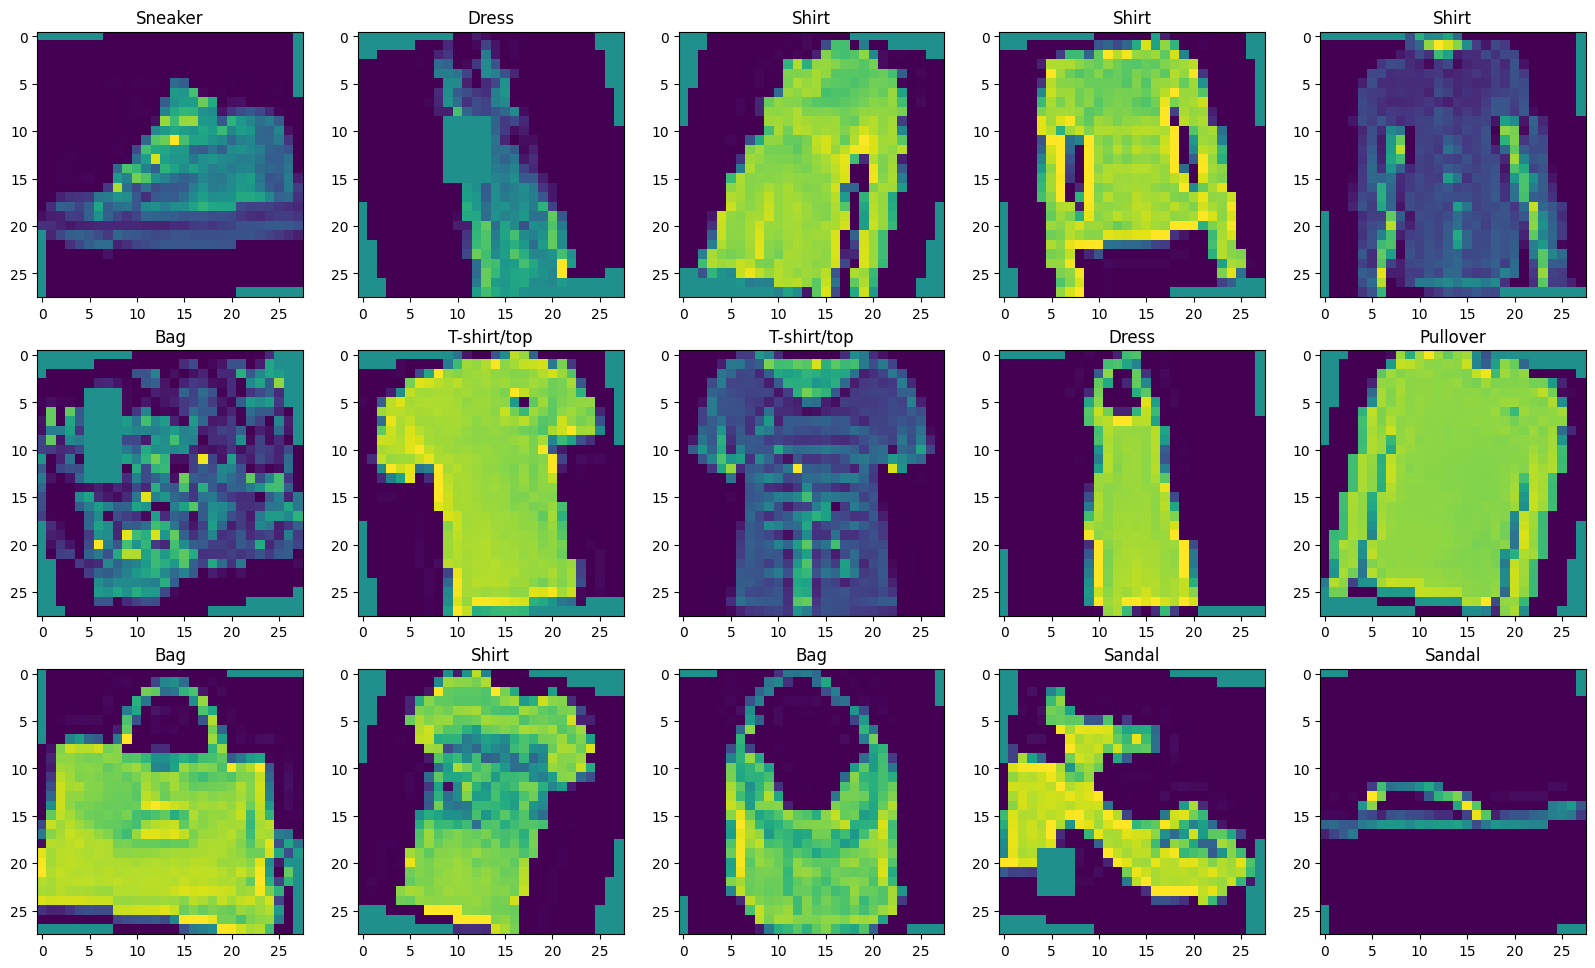

In [ ]:
import random
def show_images(data , number_images=15):
    classes = data.classes
    plt.figure(figsize=(20,20))
    for i in range(number_images):
        plt.subplot(5 , 5 , i+1)
        idx = random.randint(0 , len(data))
        x , y = data[idx]
        x = torch.squeeze(x)
        plt.imshow(x)
        plt.title(classes[y])
    plt.show()
show_images(data)

In [ ]:
train_data = data.data[train_indices.indices].reshape(-1 , 1 , 28 , 28)
train_labels = F.one_hot(data.targets[train_indices.indices],10)
test_data = test.data.reshape(-1 , 1 , 28 , 28)
test_labels = F.one_hot(test.targets , 10)
val_data = data.data[val_indices.indices].reshape(-1 , 1 , 28 , 28)
val_labels = F.one_hot(data.targets[val_indices.indices] ,10)

In [ ]:
print("Train shapes")
print(train_data.shape)
print(train_labels.shape)
print("Val shapes")
print(val_data.shape)
print(val_labels.shape)
print("Test shapes")
print(test_data.shape)
print(test_labels.shape)

Train shapes
torch.Size([48000, 1, 28, 28])
torch.Size([48000, 10])
Val shapes
torch.Size([12000, 1, 28, 28])
torch.Size([12000, 10])
Test shapes
torch.Size([10000, 1, 28, 28])
torch.Size([10000, 10])


In [ ]:
class FashionMNIST(Dataset):
    def __init__(self , X , y):
        self.X = X.to(torch.float32)
        self.y = y.to(torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, index):
        return self.X[index] , self.y[index]



In [ ]:
classes = len(data.targets)
train_dataset = FashionMNIST(train_data , train_labels)
val_dataset = FashionMNIST(val_data , val_labels)
test_dataset = FashionMNIST(test_data , test_labels)

# Main Code


CNN class

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self , input_channel , number_classes):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(in_channels=input_channel , out_channels=64 , kernel_size=3, stride=1 , padding="same"),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2), # 64 , 14 , 14

            nn.Conv2d(in_channels=64 , out_channels=128 , kernel_size=3, stride=1 , padding="same"),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(in_channels=128 , out_channels=128 , kernel_size=3, stride=1 , padding="same"),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2), # 128 , 7 , 7

            nn.Conv2d(in_channels=128 , out_channels=256 , kernel_size=3, stride=1 , padding="same"),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2) # 256 , 3 , 3

        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*3*3 , 128),
            nn.ReLU(),
            nn.Dropout(0.6),

            nn.Linear(128 , 64),
            nn.ReLU(),
            nn.Dropout(0.6),

            nn.Linear(64 , 32),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.Linear(32 , 16),
            nn.ReLU(),
            nn.Dropout(0.6),

            nn.Linear(16 , 10)

        )
    def forward(self , x):
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x



class MainExecution():
    def __init__(self, X , num_classes, train_dataset , val_dataset , test_dataset, batch_size , lr):
        self.input_channel = X.shape[1]


        self.train_batch = DataLoader(train_dataset , batch_size=batch_size , shuffle=True)
        self.val_batch = DataLoader(val_dataset , batch_size=batch_size , shuffle=False)
        self.test_batch = DataLoader(test_dataset , batch_size=batch_size , shuffle=False)

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = SimpleCNN(self.input_channel, num_classes).to(self.device)
        self.loss_fn = nn.CrossEntropyLoss()
        self.optimizer = optimizer.Adam(self.model.parameters() , lr , weight_decay=1e-5)
        self.scheduler = optimizer.lr_scheduler.StepLR(self.optimizer , step_size=10 , gamma=0.1)

        self.train_losses = None
        self.train_accuracies = None
        self.val_losses = None
        self.val_accuracies = None

    def get_model_dataloader(self):
        return self.model , self.test_batch

    def caculate_accuracy(self, y_pred , y_true):
        y_pred = torch.argmax(y_pred , dim=1)
        y_true = torch.argmax(y_true , dim=1)
        return torch.sum(y_pred == y_true).item() / len(y_true)

    def validate(self, test=False):
        data_loader = self.val_batch
        if test:
            data_loader = self.test_batch
        self.model.eval()
        total_loss = 0
        total_accuracy = 0
        with torch.no_grad():
            for X, y in data_loader:
                X, y = X.to(self.device), y.to(self.device)
                y_pred = self.model(X)
                loss = self.loss_fn(y_pred, y)
                total_loss += loss.item()
                total_accuracy += self.caculate_accuracy(y_pred, y)

        total_loss /= len(data_loader)
        total_accuracy /= len(data_loader)
        return total_loss, total_accuracy

    def plot_graphs(self):
        total_epochs = len(self.val_losses)
        if total_epochs == 0:
            print("No data to plot.")
            return
        epochs = np.arange(0 , total_epochs, 1)

        plt.figure(figsize=(14,6))

        plt.subplot(1,2,1)
        plt.plot(epochs , self.val_losses , label="Validation Loss" , color="cyan")
        plt.plot(epochs , self.train_losses , label="Train Loss" , color="orange")
        plt.title("Loss vs Epochs")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.grid(True)
        plt.legend()

        plt.subplot(1,2,2)
        plt.plot(epochs , self.val_accuracies , label="Validation Accuracy" , color="red")
        plt.plot(epochs , self.train_accuracies , label="Train Accuracy" , color="orange")
        plt.title("Accuracy vs Epochs")
        plt.xlabel("Epochs")
        plt.ylabel("Accuracy")
        plt.grid(True)
        plt.legend()

        plt.show()




    def train(self , num_epoch , show=True):
        train_losses = []
        train_accuracies = []
        val_losses = []
        val_accuracies = []

        self.model.train()
        for epoch in range(num_epoch):
            train_loss = 0
            train_accuracy = 0
            for X , y in self.train_batch:
                X , y = X.to(self.device) , y.to(self.device)
                y_pred = self.model(X)

                loss = self.loss_fn(y_pred , y)

                train_loss += loss.item()
                train_accuracy += self.caculate_accuracy(y_pred , y)

                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

            train_loss /= len(self.train_batch)
            train_accuracy /= len(self.train_batch)
            val_loss , val_accuracy = self.validate()

            if show:
                print(f"{epoch+1}/{num_epoch} -> train_loss : {train_loss:.4f} , val_loss : {val_loss:.4f} , train acc {train_accuracy:.4f} , val acc {val_accuracy:.4f}")

            train_losses.append(train_loss)
            train_accuracies.append(train_accuracy)
            val_losses.append(val_loss)
            val_accuracies.append(val_accuracy)
            self.scheduler.step()

        self.train_losses = train_losses
        self.train_accuracies = train_accuracies
        self.val_losses = val_losses
        self.val_accuracies = val_accuracies

        return train_losses , train_accuracies , val_losses , val_accuracies




In [ ]:
print(torch.cuda.is_available())

True


In [ ]:
# (self, X , num_classes, train_dataset , val_dataset , test_dataset, batch_size , lr)
model = MainExecution(train_data , classes , train_dataset , val_dataset , test_dataset , 1024 , 0.001)
train_losses , train_accuracies , val_losses , val_accuracies = model.train(50)

1/50 -> train_loss : 2.2545 , val_loss : 2.0154 , train acc 0.1436 , val acc 0.2982
2/50 -> train_loss : 1.1769 , val_loss : 0.5931 , train acc 0.5386 , val acc 0.7798
3/50 -> train_loss : 0.5132 , val_loss : 0.4363 , train acc 0.8045 , val acc 0.8336
4/50 -> train_loss : 0.4069 , val_loss : 0.3794 , train acc 0.8491 , val acc 0.8602
5/50 -> train_loss : 0.3465 , val_loss : 0.3318 , train acc 0.8740 , val acc 0.8787
6/50 -> train_loss : 0.3081 , val_loss : 0.2938 , train acc 0.8892 , val acc 0.8926
7/50 -> train_loss : 0.2845 , val_loss : 0.2903 , train acc 0.8962 , val acc 0.8939
8/50 -> train_loss : 0.2573 , val_loss : 0.2549 , train acc 0.9065 , val acc 0.9096
9/50 -> train_loss : 0.2409 , val_loss : 0.2588 , train acc 0.9116 , val acc 0.9077
10/50 -> train_loss : 0.2257 , val_loss : 0.2563 , train acc 0.9177 , val acc 0.9104
11/50 -> train_loss : 0.1933 , val_loss : 0.2271 , train acc 0.9306 , val acc 0.9186
12/50 -> train_loss : 0.1834 , val_loss : 0.2287 , train acc 0.9343 , val 

# Visualizations

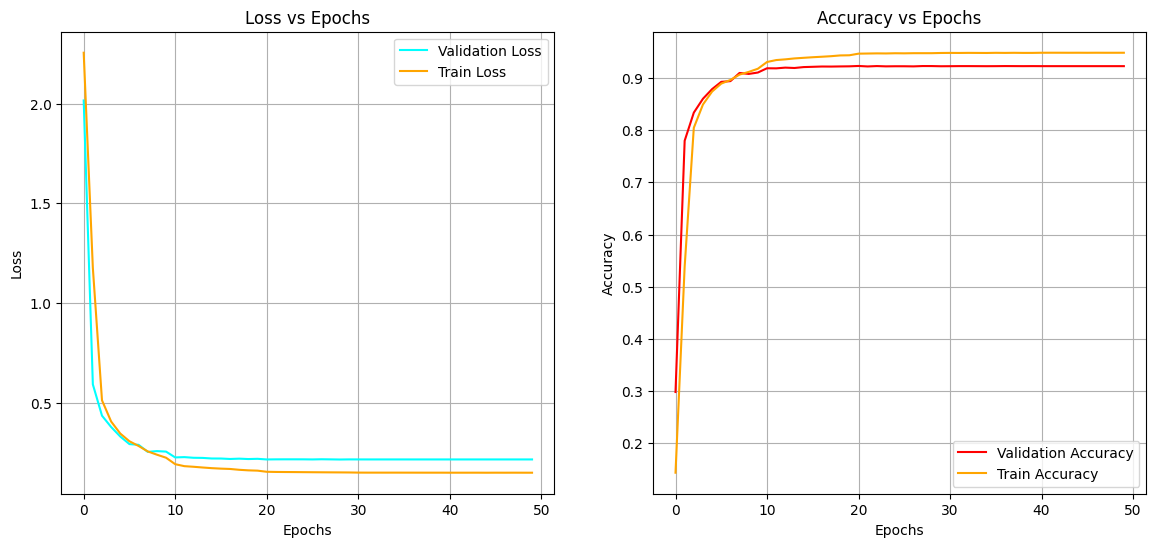

In [ ]:
model.plot_graphs()

# Evaluation

In [ ]:
print("Accuracy on Test")
loss , acc = model.validate(test=True)
print(f"Test Loss : {loss:.4f} , Test Accuracy : {acc:.4f}")

Accuracy on Test
Test Loss : 0.2360 , Test Accuracy : 0.9184


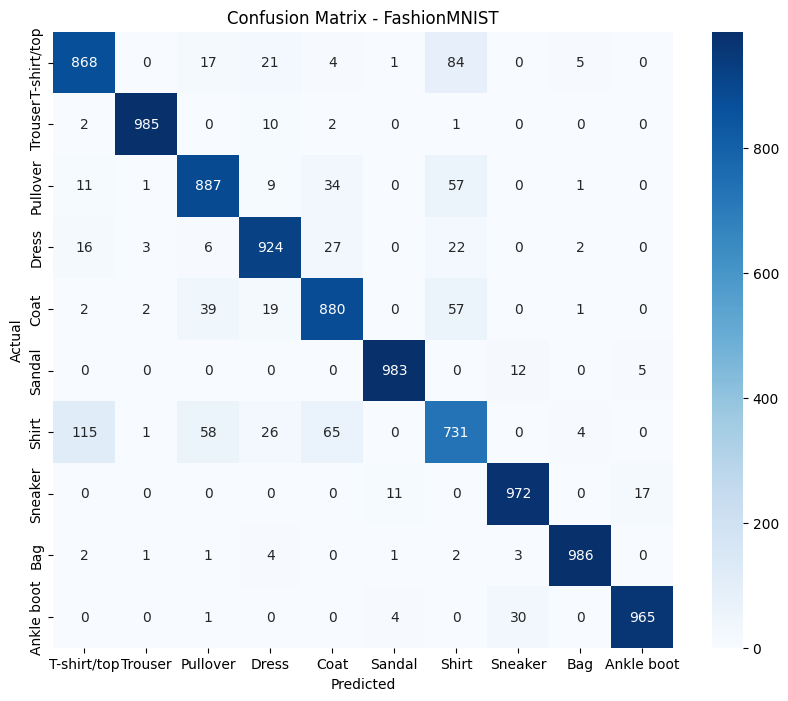

--------------------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.85      0.87      0.86      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.88      0.89      0.88      1000
       Dress       0.91      0.92      0.92      1000
        Coat       0.87      0.88      0.87      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.77      0.73      0.75      1000
     Sneaker       0.96      0.97      0.96      1000
         Bag       0.99      0.99      0.99      1000
  Ankle boot       0.98      0.96      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000

Per-Class Accuracy:
T-shirt/top: 86.80%
Trouser: 98.50%
Pullover: 88.70%
Dress: 92.40%
Coat: 88.00%
Sandal: 98.30%
Shirt: 73.10%
Sneaker:

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix , classification_report
def evaluate_model(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            labels = torch.argmax(labels, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes,
                yticklabels=classes)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix - FashionMNIST")
    plt.show()

    print("--"*40)
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=classes))
    class_accuracy = cm.diagonal() / cm.sum(axis=1)

    print("Per-Class Accuracy:")
    for idx, acc in enumerate(class_accuracy):
        print(f"{classes[idx]}: {acc*100:.2f}%")
    overall_acc = np.sum(cm.diagonal()) / np.sum(cm)
    print(f"Overall Accuracy: {overall_acc*100:.2f}%")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_ , test_batches = model.get_model_dataloader()
evaluate_model(model_, test_batches, device)